In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/tomato.zip"

Streaming output truncated to the last 5000 lines.
  inflating: tomato/Healthy/6c8f3087-94d6-4cfb-83cd-93a59f2a646a___RS_HL 0433.JPG  
  inflating: tomato/Healthy/409c349a-7738-41fc-8a3a-844cd33cfcae___RS_HL 9825.JPG  
  inflating: tomato/Healthy/388aca21-8d73-460f-8f58-a876f294f98e___GH_HL Leaf 463.JPG  
  inflating: tomato/Healthy/7b953f3c-719f-4b0e-b62d-2c651eac6c18___RS_HL 0635.JPG  
  inflating: tomato/Healthy/1e1aa3d8-d12f-47e1-b316-b8656ab3f2b6___RS_HL 0075.JPG  
  inflating: tomato/Healthy/2a1dd125-ece3-499f-a24b-1d00dbcc3184___GH_HL Leaf 227.JPG  
  inflating: tomato/Healthy/460909e5-dd8c-48f9-9a06-6daa2b3d0529___RS_HL 0341.JPG  
  inflating: tomato/Healthy/6ab4b4b5-3d4f-496b-9b08-7fa87bcfe875___RS_HL 9670.JPG  
  inflating: tomato/Healthy/5393abd2-b4e2-4af2-94d4-c52c919fc157___RS_HL 0322.JPG  
  inflating: tomato/Healthy/2b14b93f-0664-4b7f-93fa-b7d3df03dc06___GH_HL Leaf 508.1.JPG  
  inflating: tomato/Healthy/f32a71f9-5468-4169-aa2f-e895f070bfc7___RS_HL 9997.JPG  
  inflating

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import PIL.Image
import seaborn as sns
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Configuration
DATASET_DIR = "/content/tomato"
IMG_SIZE = 300
BATCH_SIZE = 32
SEED = 123
VALIDATION_SPLIT = 0.2

In [ ]:
# Show classes (subfolders) and total images in each
DATASET_DIR_ = Path(DATASET_DIR)

class_names = sorted(p.name for p in DATASET_DIR_.iterdir() if p.is_dir())
NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes:\n")

class_to_index = {name: i for i, name in enumerate(class_names)}

labels = []
total_images = 0
for name in class_names:
    class_path = DATASET_DIR_ / name
    idx = class_to_index[name]

    num_images = sum(p.is_file() for p in class_path.iterdir())
    labels += [idx] * num_images
    total_images += num_images

    print(f"{name}: {num_images} images")

print(f"\nTotal images in dataset: {total_images}")

Found 10 classes:

Bacterial_Spot: 2135 images
Early_Blight: 1008 images
Healthy: 1598 images
Late_Blight: 1919 images
Leaf_Mold: 957 images
Mosaic_Virus: 381 images
Septoria_Leaf_Spot: 1781 images
Target_Spot: 1404 images
Tomato_Spider_Mite: 1676 images
Yellow_Leaf_Curl_Virus: 3214 images

Total images in dataset: 16073


Our dataset has a class imbalance problem. This can bias the model towards the majority classes. Weights are assigned to each class so that the model can give more importance to the under-represented classes during training.

In [ ]:
# Compute class weights for imbalance
labels_ = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_),
    y=labels
)

alpha = class_weights.tolist()

print("Class Weights:")
for name_, a in zip(class_names, alpha):
    print(f"{name_}: {a:.4f}")

Class Weights:
Bacterial_Spot: 0.7528
Early_Blight: 1.5945
Healthy: 1.0058
Late_Blight: 0.8376
Leaf_Mold: 1.6795
Mosaic_Virus: 4.2186
Septoria_Leaf_Spot: 0.9025
Target_Spot: 1.1448
Tomato_Spider_Mite: 0.9590
Yellow_Leaf_Curl_Virus: 0.5001


In [ ]:
# Load the data
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Split the validation set into validation (50%) and test (50%)
# This gives us 80% train, 10% val, 10% test from the original dataset
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_size = val_batches // 2

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_ = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds_ = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds_ = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 16073 files belonging to 10 classes.
Using 12859 files for training.
Found 16073 files belonging to 10 classes.
Using 3214 files for validation.


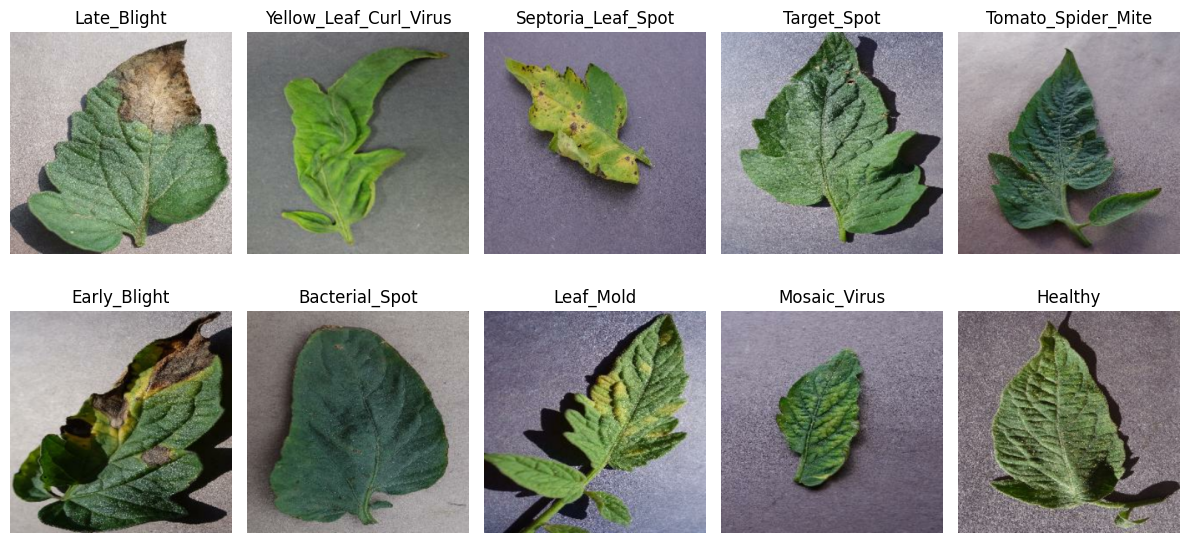

In [ ]:
# Visualize the data
# Collect one image per class
images_to_show = []
labels_to_show = []
seen_classes = set()

for images_batch, labels_batch in train_ds.take(10):
    for i in range(images_batch.shape[0]):
        class_idx = tf.argmax(labels_batch[i]).numpy()

        if class_idx not in seen_classes:
            seen_classes.add(class_idx)
            images_to_show.append(images_batch[i].numpy().astype("uint8"))
            labels_to_show.append(class_idx)

        if len(seen_classes) == 10:
            break

    if len(seen_classes) == 10:
        break

# Plot the images
plt.figure(figsize=(12, 6))
for i, image in enumerate(images_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_names[labels_to_show[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

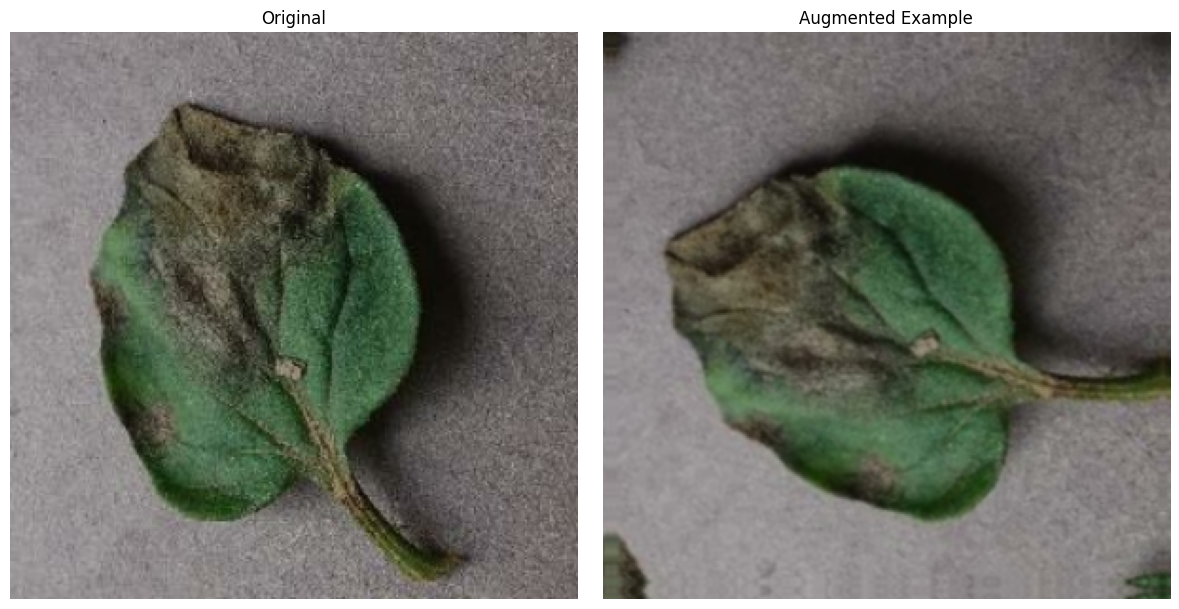

In [ ]:
# Data Augmentation
data_augmentation = [
    layers.RandomRotation(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip(),
    layers.RandomZoom(0.1),
]

# Display augmentation
def apply_augmentation(image):
    for layer in data_augmentation:
        image = layer(image)
    return image

plt.figure(figsize=(12, 6))

# Take a batch from the dataset
for images, lbls in train_ds.take(1):
    original_img = images[0]
    input_tensor = tf.expand_dims(original_img, 0)

    # Plot of Original Image in first position
    ax = plt.subplot(1, 2, 1)
    plt.imshow(original_img.numpy().astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    # Plot of Augmented example in second position
    ax = plt.subplot(1, 2, 2)
    aug_img = apply_augmentation(input_tensor)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.title("Augmented Example")
    plt.axis("off")
    break

plt.tight_layout()
plt.show()

In [ ]:
# Data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip(),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Instatiate model with pre-trained weights
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
augmented_inputs = data_augmentation(inputs)

base_model = EfficientNetV2B3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

# Freeze the pretrained weights
base_model.trainable = False

# Rebuild top
x = base_model(augmented_inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="pred")(x)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss=CategoricalFocalCrossentropy(alpha=alpha, gamma=2.0),
              metrics=["accuracy"])

In [ ]:
# Fit the model
hist = model.fit(train_ds_, epochs=10, validation_data=val_ds_)

Epoch 1/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 121s 242ms/step - accuracy: 0.6686 - loss: 0.7383 - val_accuracy: 0.8569 - val_loss: 0.2658
Epoch 2/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 228ms/step - accuracy: 0.7938 - loss: 0.4012 - val_accuracy: 0.8800 - val_loss: 0.2259
Epoch 3/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 228ms/step - accuracy: 0.8256 - loss: 0.3252 - val_accuracy: 0.9056 - val_loss: 0.1722
Epoch 4/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 142s 229ms/step - accuracy: 0.8331 - loss: 0.3161 - val_accuracy: 0.9106 - val_loss: 0.1446
Epoch 5/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 230ms/step - accuracy: 0.8403 - loss: 0.2971 - val_accuracy: 0.9050 - val_loss: 0.1732
Epoch 6/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 228ms/step - accuracy: 0.8459 - loss: 0.2810 - val_accuracy: 0.8806 - val_loss: 0.1972
Epoch 7/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 228ms/step - accuracy: 0.8525 - loss: 0.2660 - val_accuracy: 0.9069 - val_loss: 0.1758
Epoch 8/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 92s 229ms/step - accuracy: 0.8517 - loss:

In [ ]:
def plot_hist(hist):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("Model Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title("Model Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper right")

    plt.tight_layout()
    plt.show()

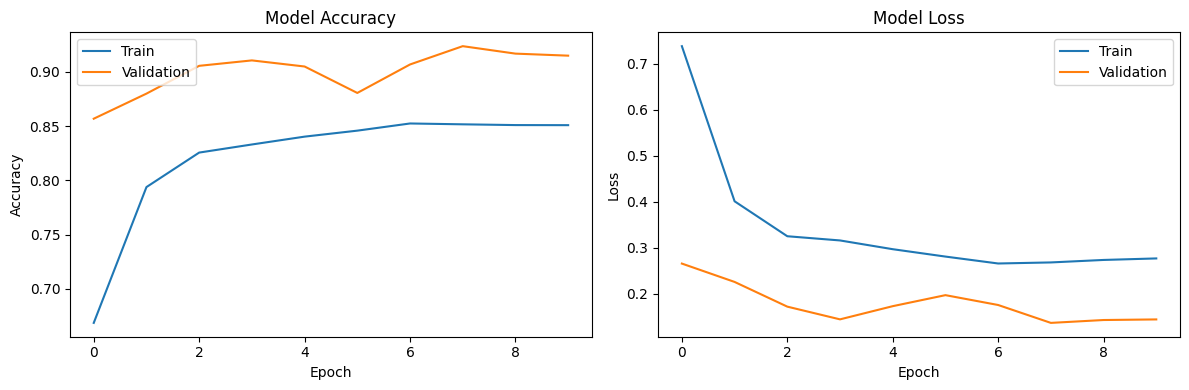

In [ ]:
plot_hist(hist)

In [ ]:
# Access the base_model layers of model
model_base_model = model.layers[2]

# Unfreeze base_model
model_base_model.trainable = True

# We unfreeze the last block while leaving BatchNorm layers frozen
for layer in model_base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif layer.name.startswith('block6'):
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=CategoricalFocalCrossentropy(alpha=alpha, gamma=2.0),
    metrics=["accuracy"]
)

In [ ]:
hist1 = model.fit(train_ds_, epochs=20, validation_data=val_ds_)

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 169s 346ms/step - accuracy: 0.8880 - loss: 0.2067 - val_accuracy: 0.9394 - val_loss: 0.1061
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 334ms/step - accuracy: 0.9140 - loss: 0.1495 - val_accuracy: 0.9619 - val_loss: 0.0807
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 333ms/step - accuracy: 0.9189 - loss: 0.1316 - val_accuracy: 0.9625 - val_loss: 0.0752
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 333ms/step - accuracy: 0.9266 - loss: 0.1177 - val_accuracy: 0.9619 - val_loss: 0.0828
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 332ms/step - accuracy: 0.9372 - loss: 0.1021 - val_accuracy: 0.9700 - val_loss: 0.0585
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 333ms/step - accuracy: 0.9421 - loss: 0.0927 - val_accuracy: 0.9688 - val_loss: 0.0611
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 134s 334ms/step - accuracy: 0.9442 - loss: 0.0819 - val_accuracy: 0.9712 - val_loss: 0.0514
Epoch 8/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 135s 335ms/step - accuracy: 0.9443 -

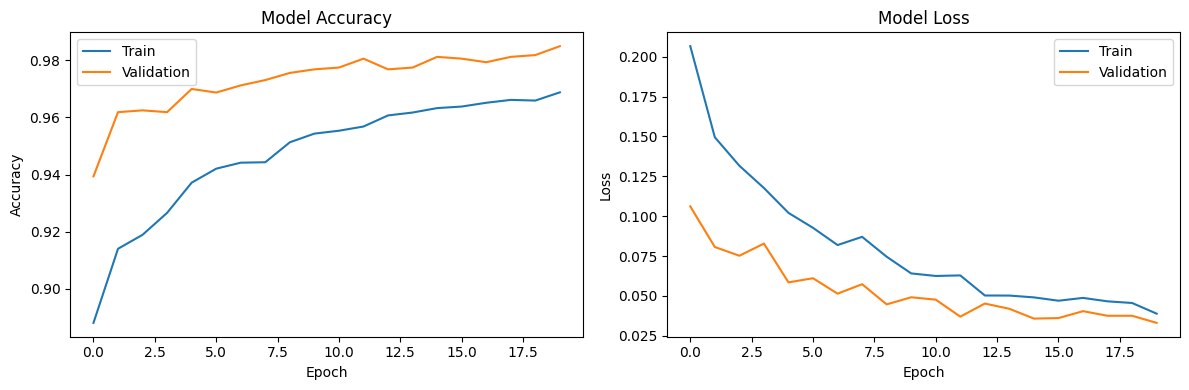

In [ ]:
plot_hist(hist1)

In [ ]:
model.evaluate(test_ds_)

51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.9814 - loss: 0.0978


[0.0977550745010376, 0.9814126491546631]

In [ ]:
# Get true labels and predictions from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds_:
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    predictions = model.predict(images)
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

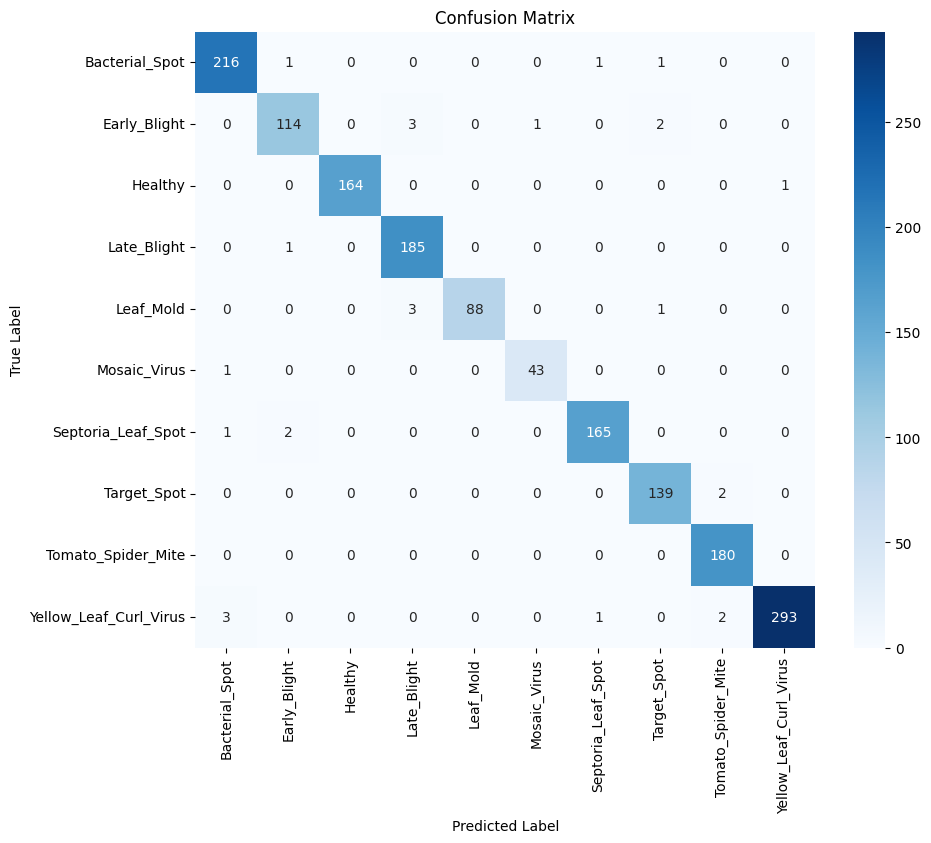

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 10)             │        15,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,786,398 (121.26 MB)

 Trainable params: 9,417,130 (35.92 MB)

 Non-trainable params: 3,535,006 (13.48 MB)

 Optimizer params: 18,834,262 (71.85 MB)

In [ ]:
inference_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
x = inference_input
for layer in model.layers[2:]:
    x = layer(x, training=False)

inference_model = tf.keras.Model(inputs=inference_input, outputs=x)

In [ ]:
inference_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 10)             │        15,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,952,136 (49.41 MB)

 Trainable params: 9,417,130 (35.92 MB)

 Non-trainable params: 3,535,006 (13.48 MB)

In [ ]:
# Convert the model
inference_model.export('modeltomato')

Saved artifact at 'modeltomato'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135216913449424: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135216913449232: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135216913449808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913450768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913451728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913450960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913450000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913452688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913452880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135216913450576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

In [ ]:
# Convert the model
converter = tf.lite.TFLiteConverter.from_saved_model('/content/modeltomato')

# Enable optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
  tf.lite.OpsSet.TFLITE_BUILTINS,
  tf.lite.OpsSet.SELECT_TF_OPS
]

# Convert the model
tflite_quant_model = converter.convert()

# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_quant_model)